# Make Figures for Fast Formation Model vs. Experiment

2024/06/13

Make clear plots of the formation data focusing on thickness expansion

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from src import plotter as plotter

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


# Plot the cycling data

In [3]:
cycling_list = ['/Users/aweng/code/formation-modeling/data/raw/from-voltaiq/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv',
                '/Users/aweng/code/formation-modeling/data/raw/from-voltaiq/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv',
                '/Users/aweng/code/formation-modeling/data/raw/from-voltaiq/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                ]

In [4]:
df_cycle_list = []
for file in cycling_list:
    df = pd.read_csv(file)
    agg = df.groupby('Cycle Number').agg({'Discharge Capacity (Ah)': 'max'})
    df_cycle_list.append(agg)

In [5]:
df = pd.read_csv(file)
headers = df.columns.tolist()
print(headers)

['[Arbin] AC Impedance (Ω)', '[Arbin] AC Impedance Phase Angle (°)', '[Arbin] Charge Capacity (Ah)', '[Arbin] Charge Energy (Wh)', '[Arbin] Current (A)', '[Arbin] Cycle Number', '[Arbin] Datapoint Number', '[Arbin] Date Time (excel format)', '[Arbin] Discharge Capacity (Ah)', '[Arbin] Discharge Energy (Wh)', '[Arbin] dV/dT (V/s)', '[Arbin] Internal Resistance (Ω)', '[Arbin] Is Fast Capture', '[Arbin] Potential (V)', '[Arbin] Step Index', '[Arbin] Step Time (s)', '[Arbin] Test Time (s)', 'Test Cumulative Capacity (Ah)', 'Test Cumulative Energy (Wh)', 'Test Net Capacity (Ah)', 'Test Net Energy (Wh)', 'dQ/dV (Ah/V)', 'dV/dt (V/s)', 'Power (W)', 'Current Cycle Net Capacity (Ah)', 'Current Cycle Net Energy (Wh)', 'Charge Capacity (Ah)', 'Charge Energy (Wh)', 'Current (A)', 'Cycle Number', 'Datapoint Number', 'Timestamp', 'Discharge Capacity (Ah)', 'Discharge Energy (Wh)', 'Potential (V)', 'Step Index', 'Step Time (s)', 'Test Time (s)']


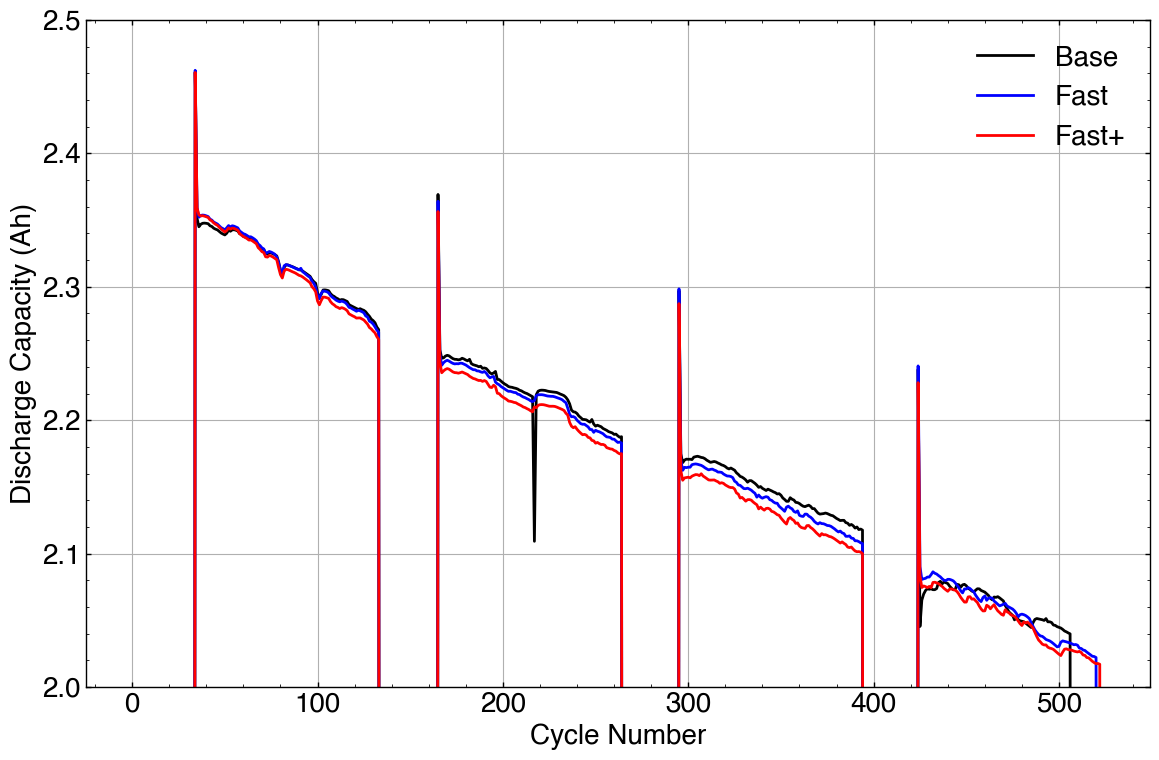

In [6]:
plt.figure(figsize=(12, 8))
cols = ['k', 'b', 'r']
labels = ['Base', 'Fast', 'Fast+']

for i, df in enumerate(df_cycle_list):

    plt.plot(df.index, df['Discharge Capacity (Ah)'], color=cols[i], label=labels[i])

plt.xlabel('Cycle Number')
plt.ylabel('Discharge Capacity (Ah)')
plt.ylim(2, 2.5)
plt.legend()

In [7]:
df

,Discharge Capacity (Ah)
Cycle Number,
1,0.092239
2,0.006946
3,0.006949
4,0.006958
5,0.006956
...,...
519,2.018255
520,2.017463
521,2.017624


In [8]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2,3])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)

    hr_max = max_hours

    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    cc = df_arbin['Cycle Number']
    qq = df_arbin['Discharge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.NaN

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.NaN

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]
    out['arbin_cycle_index'] = cc.iloc[idx]
    out['arbin_discharge_capacity'] = qq.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [9]:
expt1 = fetch_experimental_data(152064)
expt3 = fetch_experimental_data(152071)
expt4 = fetch_experimental_data(152098)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_55562/1068899767.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_55562/1068899767.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_55562/1068899767.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_g

# Plot the experimental data

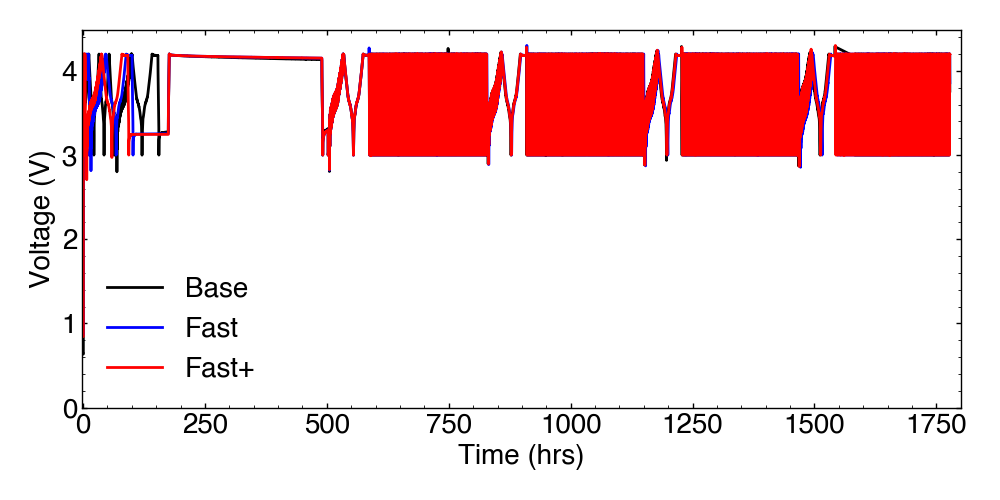

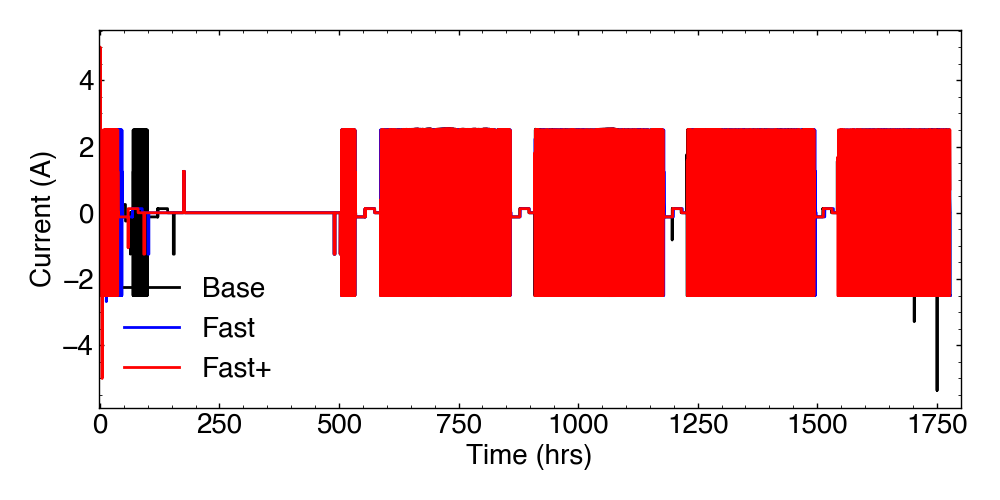

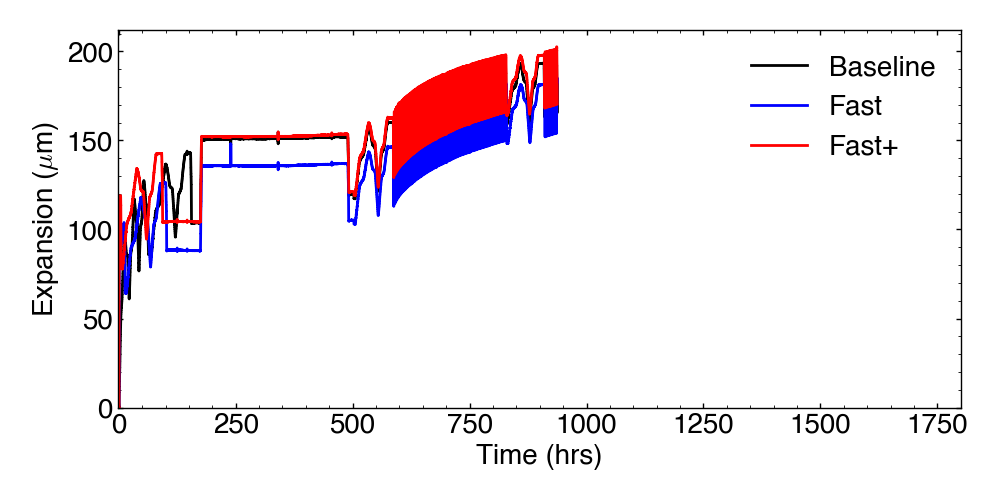

In [10]:
%matplotlib widget

# The voltage plot
plt.figure(figsize=(10,5))
ax1 = plt.gca()

XLIM = (-0.1 * 24, 1800)
ax1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base')
ax1.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast')
ax1.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+')
ax1.set_xlabel('Time (hrs)')
ax1.set_ylabel('Voltage (V)')
ax1.set_ylim(bottom=0)
ax1.legend()
ax1.grid(False)
ax1.set_xlim(XLIM)

# The current plot
plt.figure(figsize=(10,5))
ax2 = plt.gca()

ax2.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax2.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax2.set_xlabel('Time (hrs)')
ax2.set_ylabel('Current (A)')
ax2.legend()
ax2.grid(False)
ax2.set_xlim(XLIM)

# The expansion plot
plt.figure(figsize=(10,5))
ax3 = plt.gca()
ax3.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Baseline')
ax3.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast')
ax3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+')
ax3.legend()
ax3.set_ylabel(r'Expansion ($\mu$m)')
ax3.set_ylim(bottom=0, top=212)
ax3.set_xlim(XLIM)
ax3.set_xlabel('Time (hrs)')
ax3.grid(False)